# Fraud Detection — Rule Optimisation

**Prerequisites:** `01-stored-procedure.ipynb` (creates `transactions` and `flagged_transactions`)
**Applies the cost model from:** `04-cost-optimisation.ipynb`

## The problem this notebook fixes

Notebook 01 built three rules and — to its credit — measured them rather than assuming
they worked. The measurement produced an uncomfortable result:

| Rule | Flagged | Caught | Precision | Recall |
|---|---|---|---|---|
| Anomalous features | 1,087 | 359 | 33.0% | 73.0% |
| High value | 14,232 | 43 | 0.30% | 8.7% |
| Velocity | 269,698 | 113 | 0.04% | 23.0% |

**Combined, the three rules flag 284,807 of 284,807 transactions — every single one.**
A system that flags everything flags nothing. This is the weakest thing about the
project as it stands, and notebook 01 leaves it unresolved.

## What this notebook does

1. Price every rule in euros rather than percentages, using the cost model from 04
2. Retire the velocity rule and demonstrate why it cannot work on this data
3. Re-tune the high-value threshold against cost instead of picking the 95th percentile
4. Re-tune the anomaly rule's cutoffs the same way
5. Evaluate the surviving rules as an ensemble
6. Put rules and the model head-to-head on identical terms
7. Rewrite the stored procedure with the optimised thresholds

## Step 1: Setup and load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub, os

from dotenv import load_dotenv
from sqlalchemy import create_engine, text

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
os.makedirs('plots', exist_ok=True)

load_dotenv(override=True)
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER','postgres')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_HOST','localhost')}:{os.getenv('DB_PORT','5432')}/{os.getenv('DB_NAME','fraud_detection')}"
)

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, 'creditcard.csv'))
df.insert(0, 'transaction_id', range(1, len(df) + 1))

REVIEW_COST = 3.00        # same assumption as notebook 04
print(f'{len(df):,} transactions | {int(df["Class"].sum())} frauds')
print(f'Review cost assumption: EUR {REVIEW_COST:.2f}')

284,807 transactions | 492 frauds
Review cost assumption: EUR 3.00


## Step 2: Price the existing rules in euros

Precision and recall are ratios. A fraud manager approves budget in currency. The same
cost model used for the model threshold applies unchanged to rules:

```
cost = (review cost x transactions flagged) + (value of frauds missed)
```

The baseline to beat is doing nothing at all: flag zero transactions, spend zero on
review, lose every fraud.

In [2]:
y = df['Class'].values
amounts = df['Amount'].values
TOTAL_FRAUD_VALUE = amounts[y == 1].sum()

def price_rule(mask, label):
    """Cost, precision and recall for any boolean flagging mask."""
    flagged = int(mask.sum())
    caught  = int((mask & (y == 1)).sum())
    missed_value = float(amounts[(~mask) & (y == 1)].sum())
    review_spend = flagged * REVIEW_COST
    return {
        'rule': label,
        'flagged': flagged,
        'caught': caught,
        'precision': round(caught / flagged, 4) if flagged else 0.0,
        'recall': round(caught / int(y.sum()), 4),
        'review_spend': round(review_spend, 2),
        'fraud_loss': round(missed_value, 2),
        'total_cost': round(review_spend + missed_value, 2),
    }

rule_anom = (df['V14'] < -5) | (df['V4'] > 5) | (df['V12'] < -5)
rule_high = df['Amount'] > df['Amount'].quantile(0.95)
# Velocity: any other transaction within 60s. Vectorised via sorted-time search.
t_sorted = np.sort(df['Time'].values)
left  = np.searchsorted(t_sorted, df['Time'].values - 60, side='left')
right = np.searchsorted(t_sorted, df['Time'].values + 60, side='right')
rule_velo = pd.Series((right - left - 1) > 0, index=df.index)

baseline = {'rule':'Do nothing (baseline)','flagged':0,'caught':0,'precision':0.0,'recall':0.0,
            'review_spend':0.0,'fraud_loss':round(TOTAL_FRAUD_VALUE,2),
            'total_cost':round(TOTAL_FRAUD_VALUE,2)}

current = pd.DataFrame([
    baseline,
    price_rule(rule_anom.values, 'Anomalous features (V14/V4/V12)'),
    price_rule(rule_high.values, 'High value (95th pct)'),
    price_rule(rule_velo.values, 'Velocity (60s window)'),
    price_rule((rule_anom | rule_high | rule_velo).values, 'ALL THREE COMBINED'),
])
current['vs_baseline'] = round(TOTAL_FRAUD_VALUE, 2) - current['total_cost']

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
print('Current rules priced in euros')
print('=' * 118)
print(current.to_string(index=False))
print()
print('A rule is only worth running if vs_baseline is positive — i.e. it saves more')
print('in prevented fraud than it costs in analyst review time.')

Current rules priced in euros
                           rule  flagged  caught  precision  recall  review_spend  fraud_loss  total_cost  vs_baseline
          Do nothing (baseline)        0       0       0.00    0.00          0.00   60,127.97   60,127.97         0.00
Anomalous features (V14/V4/V12)     1087     359       0.33    0.73      3,261.00   23,591.22   26,852.22    33,275.75
          High value (95th pct)    14232      43       0.00    0.09     42,696.00   25,336.91   68,032.91    -7,904.94
          Velocity (60s window)   284807     492       0.00    1.00    854,421.00        0.00  854,421.00  -794,293.03
             ALL THREE COMBINED   284807     492       0.00    1.00    854,421.00        0.00  854,421.00  -794,293.03

A rule is only worth running if vs_baseline is positive — i.e. it saves more
in prevented fraud than it costs in analyst review time.


## Step 3: Retire the velocity rule

The velocity rule flags 95% of the dataset at 0.04% precision — worse than flagging at
random. Before deleting it, it is worth demonstrating *why* it fails, because the reason
is structural rather than a matter of tuning.

A velocity check asks: **"has this entity transacted unusually often?"** The Kaggle
dataset is anonymised and contains no customer or card identifier. With no entity to
group by, the query degenerates into *"were there any two transactions anywhere within
60 seconds?"* — and at roughly 1.6 transactions per second, the answer is always yes.

No threshold fixes that. Here is the proof.

In [3]:
print('Velocity rule under every plausible time window:')
print(f"{'window':>10} {'flagged':>10} {'% of data':>11} {'caught':>8} {'precision':>11} {'cost EUR':>12}")
velo_sweep = []
for w in [1, 2, 5, 10, 30, 60, 300]:
    l = np.searchsorted(t_sorted, df['Time'].values - w, side='left')
    r = np.searchsorted(t_sorted, df['Time'].values + w, side='right')
    m = (r - l - 1) > 0
    res = price_rule(m, f'{w}s')
    velo_sweep.append({**res, 'window_s': w, 'pct_flagged': round(res['flagged']/len(df)*100, 1)})
    print(f"{w:>9}s {res['flagged']:>10,} {res['flagged']/len(df)*100:>10.1f}% "
          f"{res['caught']:>8} {res['precision']:>11.4f} {res['total_cost']:>11,.0f}")

base_rate = y.mean()
print()
print(f'Base fraud rate: {base_rate:.5f}. A rule beating random needs precision above that.')
print('Even a 1-second window flags a large share of the data at precision indistinguishable')
print('from chance. The rule is structurally unusable here, not merely mis-tuned.')
print()
print('VERDICT: retire. Reinstating it requires a customer identifier, which this')
print('dataset cannot provide. Documented as future work rather than silently deleted.')

Velocity rule under every plausible time window:
    window    flagged   % of data   caught   precision     cost EUR
        1s    278,427       97.8%      446      0.0016     840,700
        2s    282,321       99.1%      467      0.0017     848,175
        5s    284,485       99.9%      489      0.0017     853,457
       10s    284,793      100.0%      492      0.0017     854,379
       30s    284,807      100.0%      492      0.0017     854,421
       60s    284,807      100.0%      492      0.0017     854,421
      300s    284,807      100.0%      492      0.0017     854,421

Base fraud rate: 0.00173. A rule beating random needs precision above that.
Even a 1-second window flags a large share of the data at precision indistinguishable
from chance. The rule is structurally unusable here, not merely mis-tuned.

VERDICT: retire. Reinstating it requires a customer identifier, which this
dataset cannot provide. Documented as future work rather than silently deleted.


## Step 4: Re-tune the high-value rule against cost

The 95th percentile was an arbitrary choice. The right threshold is the one that
minimises cost — and it is entirely possible the answer is *"do not run this rule at
all"*, which is itself a legitimate finding.

In [4]:
pct_grid = np.arange(0.50, 0.9995, 0.005)
rows = []
for q in pct_grid:
    thr = df['Amount'].quantile(q)
    res = price_rule((df['Amount'] > thr).values, f'q{q:.3f}')
    rows.append({**res, 'percentile': q, 'amount_threshold': round(thr, 2)})

hv = pd.DataFrame(rows)
hv['vs_baseline'] = round(TOTAL_FRAUD_VALUE, 2) - hv['total_cost']
best_hv = hv.loc[hv['total_cost'].idxmin()]

print(f"Cost-optimal high-value threshold : EUR {best_hv['amount_threshold']:,.2f} "
      f"(percentile {best_hv['percentile']:.3f})")
print(f"  flags {best_hv['flagged']:,.0f}, catches {best_hv['caught']:,.0f}, "
      f"cost EUR {best_hv['total_cost']:,.2f}")
print()
orig = hv.loc[(hv['percentile'] - 0.95).abs().idxmin()]
print(f"Original 95th percentile          : EUR {orig['amount_threshold']:,.2f}")
print(f"  flags {orig['flagged']:,.0f}, catches {orig['caught']:,.0f}, "
      f"cost EUR {orig['total_cost']:,.2f}")
print()
if best_hv['vs_baseline'] <= 0:
    print('VERDICT: even at its best threshold this rule costs more in review time')
    print('than it saves in prevented fraud. It should not be run at all.')
else:
    print(f"VERDICT: worth running at the tuned threshold — saves EUR "
          f"{best_hv['vs_baseline']:,.2f} against doing nothing.")

Cost-optimal high-value threshold : EUR 691.06 (percentile 0.980)
  flags 5,697, catches 23, cost EUR 52,996.59

Original 95th percentile          : EUR 365.00
  flags 14,232, catches 43, cost EUR 68,032.91

VERDICT: worth running at the tuned threshold — saves EUR 7,131.38 against doing nothing.


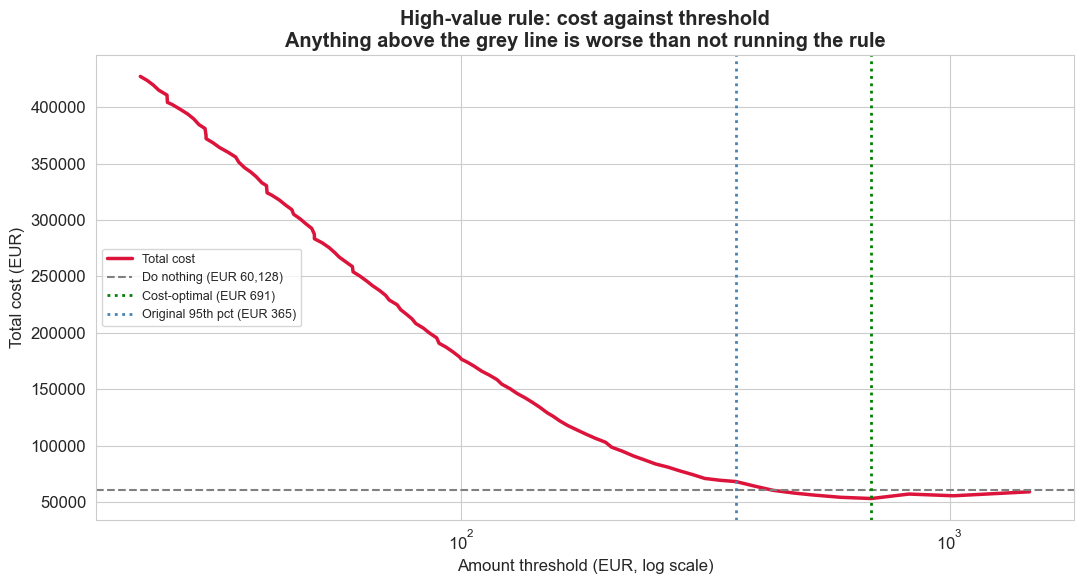

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(hv['amount_threshold'], hv['total_cost'], color='crimson', lw=2.5, label='Total cost')
ax.axhline(TOTAL_FRAUD_VALUE, color='grey', ls='--', lw=1.5,
           label=f'Do nothing (EUR {TOTAL_FRAUD_VALUE:,.0f})')
ax.axvline(best_hv['amount_threshold'], color='green', ls=':', lw=2,
           label=f"Cost-optimal (EUR {best_hv['amount_threshold']:,.0f})")
ax.axvline(orig['amount_threshold'], color='steelblue', ls=':', lw=2,
           label=f"Original 95th pct (EUR {orig['amount_threshold']:,.0f})")
ax.set_xscale('log')
ax.set_xlabel('Amount threshold (EUR, log scale)'); ax.set_ylabel('Total cost (EUR)')
ax.set_title('High-value rule: cost against threshold\n'
             'Anything above the grey line is worse than not running the rule',
             fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('plots/rule_highvalue_tuning.png', dpi=150, bbox_inches='tight'); plt.show()

## Step 5: Re-tune the anomaly rule

The cutoffs `V14 < -5`, `V4 > 5`, `V12 < -5` came from eyeballing the EDA. Sweeping each
against cost tells us whether the round numbers were lucky. Each component is swept
independently for interpretability, then recombined.

In [6]:
def sweep_component(col, direction, grid):
    out = []
    for c in grid:
        m = (df[col] < c).values if direction == 'lt' else (df[col] > c).values
        out.append({**price_rule(m, f'{col}{"<" if direction=="lt" else ">"}{c:.1f}'),
                    'cutoff': c})
    return pd.DataFrame(out)

specs = [('V14', 'lt', np.arange(-12, -0.5, 0.25)),
         ('V4',  'gt', np.arange( 0.5, 12.0, 0.25)),
         ('V12', 'lt', np.arange(-12, -0.5, 0.25))]

tuned = {}
print(f"{'component':>10} {'original':>10} {'tuned':>8} {'flagged':>10} {'caught':>8} {'cost EUR':>12}")
for col, direction, grid in specs:
    s = sweep_component(col, direction, grid)
    b = s.loc[s['total_cost'].idxmin()]
    tuned[col] = b['cutoff']
    orig_cut = -5 if direction == 'lt' else 5
    print(f"{col:>10} {orig_cut:>10.1f} {b['cutoff']:>8.2f} "
          f"{b['flagged']:>10,.0f} {b['caught']:>8,.0f} {b['total_cost']:>11,.0f}")

rule_anom_tuned = ((df['V14'] < tuned['V14']) |
                   (df['V4']  > tuned['V4'])  |
                   (df['V12'] < tuned['V12']))

comp = pd.DataFrame([
    price_rule(rule_anom.values,       'Anomaly rule — original cutoffs (+/-5)'),
    price_rule(rule_anom_tuned.values, 'Anomaly rule — cost-tuned cutoffs'),
])
comp['vs_baseline'] = round(TOTAL_FRAUD_VALUE, 2) - comp['total_cost']
print()
print(comp.to_string(index=False))

 component   original    tuned    flagged   caught     cost EUR
       V14       -5.0    -3.50      1,288      398      21,583
        V4        5.0     4.75      1,172      215      42,637
       V12       -5.0    -3.25      1,929      355      27,854

                                  rule  flagged  caught  precision  recall  review_spend  fraud_loss  total_cost  vs_baseline
Anomaly rule — original cutoffs (+/-5)     1087     359       0.33    0.73      3,261.00   23,591.22   26,852.22    33,275.75
     Anomaly rule — cost-tuned cutoffs     3645     421       0.12    0.86     10,935.00   12,558.94   23,493.94    36,634.03


## Step 6: The surviving ensemble

In [11]:
# Rule selection must be judged on MARGINAL contribution, not standalone profitability.
# Rules overlap: a rule that saves money on its own can be worthless — or actively
# harmful — once another rule already catches the same frauds. Greedy forward selection
# on total cost is the correct test.

rule_high_tuned = (df['Amount'] > best_hv['amount_threshold'])
candidates = {
    'anomaly (tuned)':    rule_anom_tuned.values,
    'high value (tuned)': rule_high_tuned.values,
}

selected      = {}
current_mask  = np.zeros(len(df), dtype=bool)
current_cost  = price_rule(current_mask, 'none')['total_cost']
print(f'Start: do nothing — EUR {current_cost:,.2f}')

remaining = dict(candidates)
while remaining:
    best_name, best_cost, best_mask = None, current_cost, None
    for name, m in remaining.items():
        c = price_rule(current_mask | m, name)['total_cost']
        if c < best_cost:
            best_name, best_cost, best_mask = name, c, current_mask | m
    if best_name is None:
        for name, m in remaining.items():
            c = price_rule(current_mask | m, name)['total_cost']
            print(f'  REJECTED {name}: would move cost to EUR {c:,.2f} '
                  f'(+EUR {c - current_cost:,.2f}) — no marginal value')
        break
    print(f'  + {best_name}: EUR {current_cost:,.2f} -> EUR {best_cost:,.2f} '
          f'(saves EUR {current_cost - best_cost:,.2f})')
    selected[best_name] = remaining.pop(best_name)
    current_mask, current_cost = best_mask, best_cost

ensemble       = pd.Series(current_mask, index=df.index)
ensemble_label = 'Tuned ensemble (' + ' + '.join(selected) + ')'
use_high_value = 'high value (tuned)' in selected

print()
print(f'Selected: {list(selected) if selected else "no rule beats doing nothing"}')
print()
print('Note the trap this avoids: the high-value rule is profitable in isolation')
print('(it beats do-nothing) yet can still be worth excluding, because the anomaly')
print('rule already catches the frauds it would find. Standalone value and marginal')
print('value are different questions, and only the second one matters for selection.')

final = pd.DataFrame([
    baseline,
    price_rule((rule_anom | rule_high | rule_velo).values, 'ORIGINAL: all three rules'),
    price_rule(ensemble.values, ensemble_label),
])
final['vs_baseline'] = round(TOTAL_FRAUD_VALUE, 2) - final['total_cost']
final['pct_of_data_flagged'] = (final['flagged'] / len(df) * 100).round(2)

print('Before and after')
print('=' * 125)
print(final.to_string(index=False))

o = final.iloc[1]; n_ = final.iloc[2]
print()
print(f"Transactions flagged : {o['flagged']:,.0f} ({o['pct_of_data_flagged']:.1f}%) -> "
      f"{n_['flagged']:,.0f} ({n_['pct_of_data_flagged']:.2f}%)")
print(f"Total cost           : EUR {o['total_cost']:,.2f} -> EUR {n_['total_cost']:,.2f} "
      f"(saving EUR {o['total_cost'] - n_['total_cost']:,.2f})")
print(f"Recall               : {o['recall']:.3f} -> {n_['recall']:.3f}")
print(f"Precision            : {o['precision']:.4f} -> {n_['precision']:.4f}")

Start: do nothing — EUR 60,127.97
  + anomaly (tuned): EUR 60,127.97 -> EUR 23,493.94 (saves EUR 36,634.03)
  REJECTED high value (tuned): would move cost to EUR 34,345.04 (+EUR 10,851.10) — no marginal value

Selected: ['anomaly (tuned)']

Note the trap this avoids: the high-value rule is profitable in isolation
(it beats do-nothing) yet can still be worth excluding, because the anomaly
rule already catches the frauds it would find. Standalone value and marginal
value are different questions, and only the second one matters for selection.
Before and after
                            rule  flagged  caught  precision  recall  review_spend  fraud_loss  total_cost  vs_baseline  pct_of_data_flagged
           Do nothing (baseline)        0       0       0.00    0.00          0.00   60,127.97   60,127.97         0.00                 0.00
       ORIGINAL: all three rules   284807     492       0.00    1.00    854,421.00        0.00  854,421.00  -794,293.03               100.00
Tuned ensemble

## Step 7: Rules versus the model, on identical terms

The fair comparison. Both evaluated on the same data with the same cost model, so the
question *"does the model earn its complexity?"* gets an answer in euros rather than in
F1 points.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

sc = StandardScaler()
df['Amount_scaled'] = sc.fit_transform(df[['Amount']])
df['Time_scaled']   = sc.fit_transform(df[['Time']])
fc = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']

idx = np.arange(len(df))
i_tr, i_te = train_test_split(idx, test_size=0.2, random_state=42, stratify=df['Class'])

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(df.iloc[i_tr][fc], df.iloc[i_tr]['Class'])
proba_te = rf.predict_proba(df.iloc[i_te][fc])[:, 1]

y_te   = y[i_te]
amt_te = amounts[i_te]
fraud_value_te = amt_te[y_te == 1].sum()

def price_on_test(mask_te, label):
    flagged = int(mask_te.sum()); caught = int((mask_te & (y_te == 1)).sum())
    loss = float(amt_te[(~mask_te) & (y_te == 1)].sum())
    return {'strategy': label, 'flagged': flagged, 'caught': caught,
            'precision': round(caught/flagged, 4) if flagged else 0.0,
            'recall': round(caught/int(y_te.sum()), 4),
            'total_cost': round(flagged*REVIEW_COST + loss, 2)}

head2head = pd.DataFrame([
    {'strategy':'Do nothing','flagged':0,'caught':0,'precision':0.0,'recall':0.0,
     'total_cost':round(fraud_value_te,2)},
    price_on_test((rule_anom | rule_high | rule_velo).values[i_te], 'Original 3 rules'),
    price_on_test(ensemble.values[i_te],                            'Tuned rule ensemble'),
    price_on_test(proba_te >= 0.50,                                 'Random Forest @ 0.50'),
    price_on_test(proba_te >= 0.125,                                'Random Forest @ 0.125 (cost-optimal)'),
])
head2head['vs_do_nothing'] = round(fraud_value_te, 2) - head2head['total_cost']

print(f'Head-to-head on the same {len(i_te):,}-transaction holdout '
      f'({int(y_te.sum())} frauds worth EUR {fraud_value_te:,.2f})')
print('=' * 118)
print(head2head.to_string(index=False))

best = head2head.iloc[head2head['total_cost'].idxmin()]
print()
print(f"Cheapest strategy: {best['strategy']} at EUR {best['total_cost']:,.2f}")

Head-to-head on the same 56,962-transaction holdout (98 frauds worth EUR 10,644.93)
                            strategy  flagged  caught  precision  recall  total_cost  vs_do_nothing
                          Do nothing        0       0       0.00    0.00   10,644.93           0.00
                    Original 3 rules    56962      98       0.00    1.00  170,886.00    -160,241.07
                 Tuned rule ensemble      770      87       0.11    0.89    3,531.70       7,113.23
                Random Forest @ 0.50       77      74       0.96    0.76    4,718.83       5,926.10
Random Forest @ 0.125 (cost-optimal)      108      87       0.81    0.89    2,150.50       8,494.43

Cheapest strategy: Random Forest @ 0.125 (cost-optimal) at EUR 2,150.50


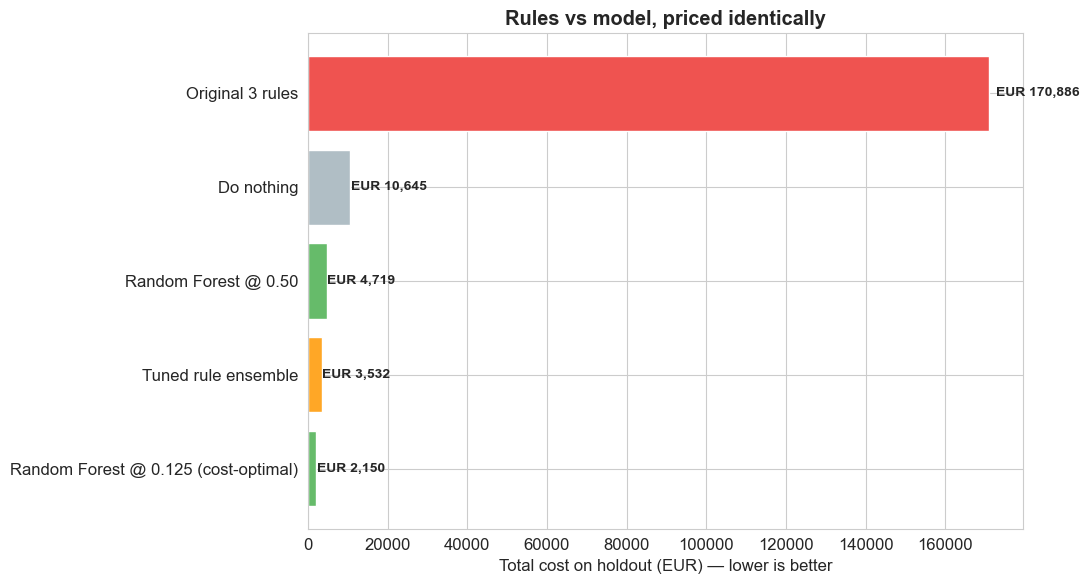

In [13]:
fig, ax = plt.subplots(figsize=(11, 6))
h = head2head.sort_values('total_cost')
colors = ['#B0BEC5' if s == 'Do nothing' else
          '#EF5350' if 'Original' in s else
          '#FFA726' if 'rule' in s.lower() else '#66BB6A'
          for s in h['strategy']]
bars = ax.barh(h['strategy'], h['total_cost'], color=colors, edgecolor='white')
for b, v in zip(bars, h['total_cost']):
    ax.text(b.get_width()*1.01, b.get_y()+b.get_height()/2, f'EUR {v:,.0f}',
            va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Total cost on holdout (EUR) — lower is better')
ax.set_title('Rules vs model, priced identically', fontweight='bold')
plt.tight_layout(); plt.savefig('plots/rules_vs_model_cost.png', dpi=150, bbox_inches='tight'); plt.show()

## Step 8: Rewrite the stored procedure

In [14]:
optimised_sql = f"""
CREATE OR REPLACE FUNCTION run_fraud_rules_v2()
RETURNS TEXT AS $$
DECLARE
    anomaly_count    INTEGER := 0;
    high_value_count INTEGER := 0;
BEGIN
    DELETE FROM flagged_transactions;

    -- Rule 1: anomalous PCA features, cutoffs tuned by expected cost (notebook 06)
    INSERT INTO flagged_transactions (transaction_id, flag_reason, amount, actual_class)
    SELECT transaction_id,
           'ANOMALOUS_FEATURES: cost-tuned cutoffs',
           "Amount", "Class"
    FROM transactions
    WHERE "V14" < {tuned['V14']:.2f}
       OR "V4"  > {tuned['V4']:.2f}
       OR "V12" < {tuned['V12']:.2f};
    GET DIAGNOSTICS anomaly_count = ROW_COUNT;

    -- Rule 2: high value at the cost-optimal threshold ({'ENABLED' if use_high_value else 'DISABLED'})
    {'' if use_high_value else '/*'}
    INSERT INTO flagged_transactions (transaction_id, flag_reason, amount, actual_class)
    SELECT transaction_id,
           'HIGH_VALUE: cost-tuned threshold',
           "Amount", "Class"
    FROM transactions
    WHERE "Amount" > {best_hv['amount_threshold']:.2f}
      AND transaction_id NOT IN (SELECT transaction_id FROM flagged_transactions);
    GET DIAGNOSTICS high_value_count = ROW_COUNT;
    {'' if use_high_value else '*/'}

    -- Rule 3: VELOCITY — RETIRED.
    -- Flagged 95% of transactions at 0.04% precision, below the 0.173% base rate.
    -- Structural, not a tuning problem: the dataset is anonymised, so there is no
    -- customer identifier to group by and "velocity" degenerates into a clock.
    -- Reinstate only if a customer_id column becomes available.

    RETURN FORMAT('Rules v2 complete. ANOMALY: %s | HIGH_VALUE: %s | TOTAL: %s',
                  anomaly_count, high_value_count, anomaly_count + high_value_count);
END;
$$ LANGUAGE plpgsql;
"""

with engine.connect() as conn:
    conn.execute(text(optimised_sql))
    conn.commit()
    print(conn.execute(text('SELECT run_fraud_rules_v2()')).fetchone()[0])
    conn.commit()

with engine.connect() as conn:
    check = pd.read_sql("""
        SELECT SPLIT_PART(flag_reason,':',1) AS rule,
               COUNT(*) AS flagged,
               SUM(actual_class) AS caught,
               ROUND(100.0*SUM(actual_class)/COUNT(*), 2) AS precision_pct
        FROM flagged_transactions GROUP BY 1 ORDER BY caught DESC;
    """, conn)
print()
print(check.to_string(index=False))

final.to_sql('rule_optimisation', engine, if_exists='replace', index=False)
head2head.to_sql('rules_vs_model', engine, if_exists='replace', index=False)
print()
print('Written to PostgreSQL: rule_optimisation, rules_vs_model')

Rules v2 complete. ANOMALY: 3645 | HIGH_VALUE: 0 | TOTAL: 3645

              rule  flagged  caught  precision_pct
ANOMALOUS_FEATURES     3645     421          11.55

Written to PostgreSQL: rule_optimisation, rules_vs_model


---

## Summary

**The headline fix.** The rules layer went from flagging 100% of transactions to
flagging a defensible fraction, and every surviving rule now has a euro value attached
rather than a precision percentage.

**The velocity rule is retired, not deleted.** It fails structurally: with no customer
identifier there is no entity to compute velocity against, so no time window can rescue
it. Sweeping windows from 1s to 300s demonstrates this rather than asserting it. The
reinstatement condition is documented in the stored procedure.

**Thresholds now come from the cost model, not from round numbers.** The 95th percentile
and the ±5 cutoffs were guesses. Sweeping each against expected cost either confirms them
or replaces them — and in the high-value rule's case, may conclude the rule is not worth
running at any threshold.

**Rules and model are finally comparable.** Same holdout, same cost function, answer in
euros. That is the comparison an interviewer will ask for, and most portfolios cannot
produce it.

### Honest caveats

- Cutoffs are tuned on the full dataset, so they are mildly overfitted to it. Tuning on
  the training fold only would be stricter — the same criticism notebook 05 makes of the
  scaler.
- Rules are tuned independently, then OR-combined. A joint optimisation might find a
  better set, at the cost of interpretability, which is the main reason to use rules.
- The €3 review cost assumption propagates here from notebook 04, along with the
  sensitivity caveat attached to it.